In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import mlflow

In [2]:
PROJECT_ROOT = os.path.abspath("..")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "loan_approval_dataset.csv")
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")

df = pd.read_csv(DATA_PATH)

preprocessor = joblib.load(os.path.join(ARTIFACTS_DIR, "preprocessor.joblib"))
model = joblib.load(os.path.join(ARTIFACTS_DIR, "best_model.joblib"))

In [3]:
target_col = "loan_status"

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"approved": 1, "rejected": 0})
)

In [4]:
drop_cols = [col for col in ["loan_id", "Loan_ID"] if col in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

In [5]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
X_processed = preprocessor.transform(X)

In [7]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names[:20])
print("Total transformed features:", len(feature_names))

['num__no_of_dependents' 'num__income_annum' 'num__loan_amount'
 'num__loan_term' 'num__cibil_score' 'num__residential_assets_value'
 'num__commercial_assets_value' 'num__luxury_assets_value'
 'num__bank_asset_value' 'cat__education_ Graduate'
 'cat__education_ Not Graduate' 'cat__self_employed_ No'
 'cat__self_employed_ Yes']
Total transformed features: 13


In [8]:
X_processed_df = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=feature_names
)

In [10]:
booster = model.get_booster()

In [11]:
import xgboost as xgb
import pandas as pd
import numpy as np

dmat = xgb.DMatrix(X_processed_df, feature_names=X_processed_df.columns.tolist())

In [12]:
contribs = booster.predict(dmat, pred_contribs=True)
print(contribs.shape)

(4269, 14)


In [13]:
contrib_cols = X_processed_df.columns.tolist() + ["bias"]

contrib_df = pd.DataFrame(contribs, columns=contrib_cols, index=X_processed_df.index)
contrib_df.head()

,num__no_of_dependents,num__income_annum,num__loan_amount,num__loan_term,num__cibil_score,num__residential_assets_value,num__commercial_assets_value,num__luxury_assets_value,num__bank_asset_value,cat__education_ Graduate,cat__education_ Not Graduate,cat__self_employed_ No,cat__self_employed_ Yes,bias
0,-0.032758,-0.991521,1.129502,-1.422190,6.908094,0.731060,0.503562,-0.043251,0.172533,-0.039683,-0.004506,-0.022195,-0.008943,0.467932
1,0.113179,-0.041330,-0.418809,-2.902763,-4.357502,0.513540,0.210311,0.014988,0.080512,0.085375,0.015043,-0.041761,0.011334,0.467932
2,0.087621,-1.196838,1.939177,-3.502539,-4.263779,0.445983,0.305618,-0.151370,0.089152,-0.042254,-0.003683,-0.029417,-0.012018,0.467932
3,0.112250,-1.005024,2.238828,-3.306050,-4.173214,-0.016083,0.318812,-0.233467,0.065078,-0.018922,-0.003814,-0.021657,-0.007527,0.467932
4,-0.155613,-1.380561,0.798874,-2.567032,-4.535864,0.106764,0.015934,-0.159319,0.098018,0.040781,0.009109,0.041038,0.015732,0.467932


In [14]:
row_idx = 0   # or any row index you want

row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()
print("Top negative contributors:")
print(row_contrib.head(5))

print("\nTop positive contributors:")
print(row_contrib.tail(5))

Top negative contributors:
num__loan_term             -1.422190
num__income_annum          -0.991521
num__luxury_assets_value   -0.043251
cat__education_ Graduate   -0.039683
num__no_of_dependents      -0.032758
Name: 0, dtype: float32

Top positive contributors:
num__bank_asset_value            0.172533
num__commercial_assets_value     0.503562
num__residential_assets_value    0.731060
num__loan_amount                 1.129502
num__cibil_score                 6.908094
Name: 0, dtype: float32


In [15]:
global_importance = contrib_df.drop(columns=["bias"]).abs().mean().sort_values(ascending=False)

global_importance_df = global_importance.reset_index()
global_importance_df.columns = ["feature", "mean_abs_contribution"]

global_importance_df.head(10)

,feature,mean_abs_contribution
0,num__cibil_score,5.457511
1,num__loan_term,1.900409
2,num__loan_amount,0.763337
3,num__income_annum,0.647750
4,num__residential_assets_value,0.582906
5,num__commercial_assets_value,0.354545
6,num__bank_asset_value,0.162031
7,num__luxury_assets_value,0.144655
8,num__no_of_dependents,0.092542
9,cat__education_ Graduate,0.058281


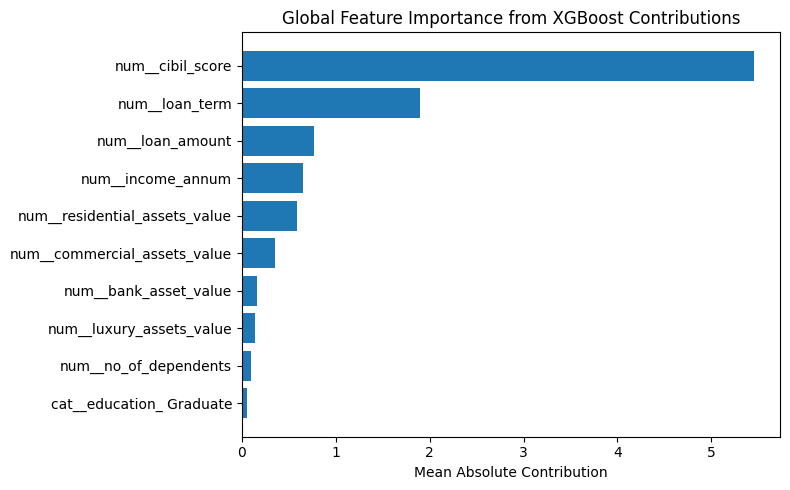

In [16]:
import matplotlib.pyplot as plt

top_n = 10
plot_df = global_importance_df.head(top_n).sort_values("mean_abs_contribution")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["mean_abs_contribution"])
plt.title("Global Feature Importance from XGBoost Contributions")
plt.xlabel("Mean Absolute Contribution")
plt.tight_layout()
plt.show()

In [17]:
def explain_row(contrib_df, row_idx, top_n=5):
    row = contrib_df.loc[row_idx].drop("bias").sort_values()
    top_negative = row.head(top_n)
    top_positive = row.tail(top_n).sort_values(ascending=False)
    return top_positive, top_negative

In [18]:
top_pos, top_neg = explain_row(contrib_df, row_idx=0, top_n=5)

print("Top positive contributors:")
print(top_pos)

print("\nTop negative contributors:")
print(top_neg)

Top positive contributors:
num__cibil_score                 6.908094
num__loan_amount                 1.129502
num__residential_assets_value    0.731060
num__commercial_assets_value     0.503562
num__bank_asset_value            0.172533
Name: 0, dtype: float32

Top negative contributors:
num__loan_term             -1.422190
num__income_annum          -0.991521
num__luxury_assets_value   -0.043251
cat__education_ Graduate   -0.039683
num__no_of_dependents      -0.032758
Name: 0, dtype: float32


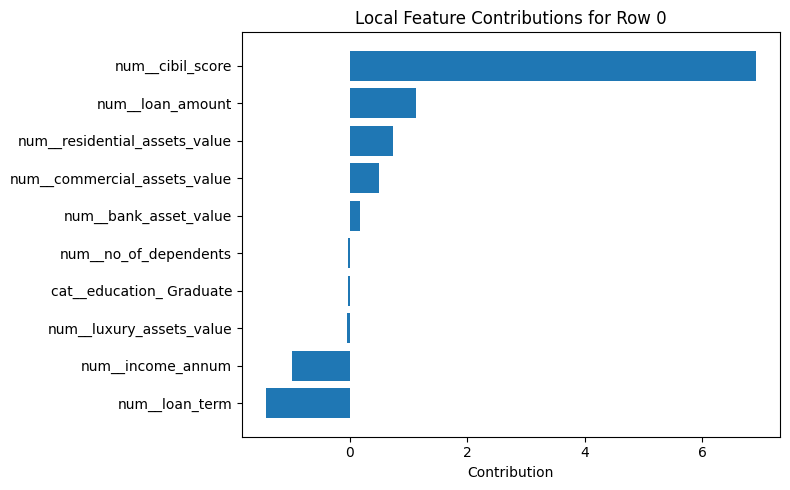

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

row_idx = 0

row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()

top_negative = row_contrib.head(5)
top_positive = row_contrib.tail(5)

local_plot_df = pd.concat([top_negative, top_positive]).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(local_plot_df.index, local_plot_df.values)
plt.title(f"Local Feature Contributions for Row {row_idx}")
plt.xlabel("Contribution")
plt.tight_layout()
plt.show()

In [21]:
row_idx = 0

row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()
top_negative = row_contrib.head(5)
top_positive = row_contrib.tail(5)

print("Features pushing toward rejection:")
for feature, value in top_negative.items():
    print(f"{feature}: {value:.4f}")

print("\nFeatures pushing toward approval:")
for feature, value in top_positive.sort_values(ascending=False).items():
    print(f"{feature}: {value:.4f}")

Features pushing toward rejection:
num__loan_term: -1.4222
num__income_annum: -0.9915
num__luxury_assets_value: -0.0433
cat__education_ Graduate: -0.0397
num__no_of_dependents: -0.0328

Features pushing toward approval:
num__cibil_score: 6.9081
num__loan_amount: 1.1295
num__residential_assets_value: 0.7311
num__commercial_assets_value: 0.5036
num__bank_asset_value: 0.1725


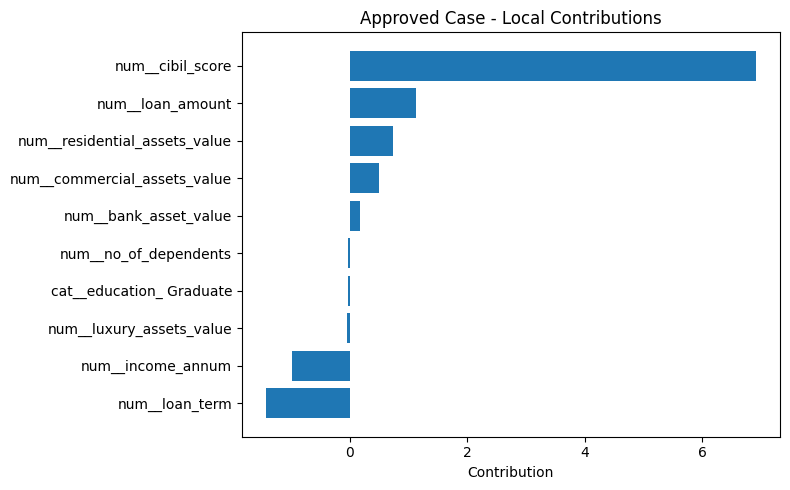

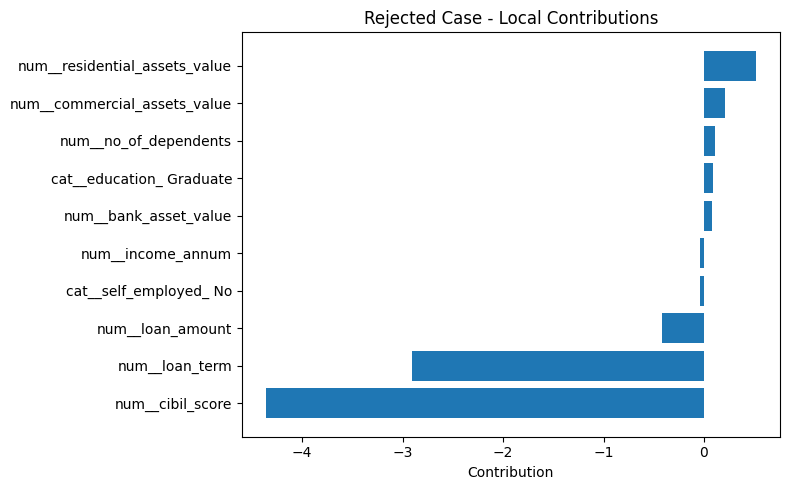

In [22]:
approved_idx = y[y == 1].index[0]
rejected_idx = y[y == 0].index[0]

def plot_local_contributions(contrib_df, row_idx, title):
    row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()
    top_negative = row_contrib.head(5)
    top_positive = row_contrib.tail(5)
    local_plot_df = pd.concat([top_negative, top_positive]).sort_values()

    plt.figure(figsize=(8, 5))
    plt.barh(local_plot_df.index, local_plot_df.values)
    plt.title(title)
    plt.xlabel("Contribution")
    plt.tight_layout()
    plt.show()

plot_local_contributions(contrib_df, approved_idx, "Approved Case - Local Contributions")
plot_local_contributions(contrib_df, rejected_idx, "Rejected Case - Local Contributions")